# Model C — Idle State CNN
**4-class classification:** `normal_engine_idle` / `low_oil` / `power_steering` / `serpentine_belt`

- Input: `(40, 78, 1)` — 40 MFCCs x 78 time frames x 1 channel
- Architecture: same backbone as Models A & B, wider third conv (64 filters), 4-class head
- Data: `data/processed/idle.npz` — 1290 train / 93 val / 93 test
- Class imbalance: `normal_engine_idle` 2.25x larger than fault classes → balanced class weights applied

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))
os.chdir(os.path.dirname(os.getcwd())) if os.path.basename(os.getcwd()) == 'notebooks' else None

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.train_idle import (
    build_model, load_splits, compute_class_weights,
    plot_training_curves, plot_confusion_matrix,
)

print(f'TensorFlow {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow 2.19.0
GPU available: False


## 1 — Load Data

In [2]:
X_train, X_val, X_test, y_train, y_val, y_test, label_names = load_splits()

print(f'Train : {X_train.shape}  dist: {np.bincount(y_train)}')
print(f'Val   : {X_val.shape}   dist: {np.bincount(y_val)}')
print(f'Test  : {X_test.shape}  dist: {np.bincount(y_test)}')
print(f'Classes: {label_names}')
print()

# Show imbalance clearly
counts = np.bincount(y_train)
print('Imbalance ratio (normal vs fault classes):')
for i, (name, count) in enumerate(zip(label_names, counts)):
    ratio = count / counts[1:].mean()
    print(f'  {name:<25} {count:>4}  ({ratio:.2f}x avg fault count)')

Train : (1290, 40, 78, 1)  dist: [552 225 270 243]
Val   : (93, 40, 78, 1)   dist: [40 16 20 17]
Test  : (93, 40, 78, 1)  dist: [40 16 19 18]
Classes: [np.str_('normal_engine_idle'), np.str_('low_oil'), np.str_('power_steering'), np.str_('serpentine_belt')]

Imbalance ratio (normal vs fault classes):
  normal_engine_idle         552  (2.24x avg fault count)
  low_oil                    225  (0.91x avg fault count)
  power_steering             270  (1.10x avg fault count)
  serpentine_belt            243  (0.99x avg fault count)


## 2 — Class Weights

Class weights:
  class 0: 0.584
  class 1: 1.433
  class 2: 1.194
  class 3: 1.327


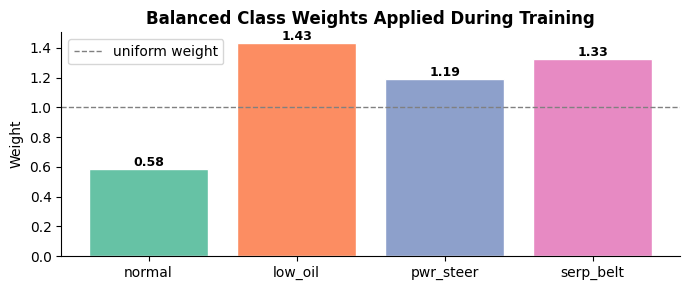

In [3]:
class_weights = compute_class_weights(y_train)

fig, ax = plt.subplots(figsize=(7, 3))
short = ['normal', 'low_oil', 'pwr_steer', 'serp_belt']
bars = ax.bar(short, list(class_weights.values()),
              color=plt.cm.Set2.colors[:4], edgecolor='white')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1, label='uniform weight')
for bar, v in zip(bars, class_weights.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Balanced Class Weights Applied During Training', fontweight='bold')
ax.set_ylabel('Weight')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('results/idle_class_weights.png', bbox_inches='tight')
plt.show()

## 3 — Architecture

In [4]:
model = build_model(input_shape=(40, 78, 1), n_classes=4)
model.summary()

total_params = model.count_params()
size_kb = total_params * 4 / 1024
print(f'\nParam count : {total_params:,}')
print(f'Float32 size: {size_kb:.1f} KB')
print(f'TFLite int8 estimate: ~{size_kb/4:.1f} KB  (target: < 100 KB)')

Model: "idle_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40, 78, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 78, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 78, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 39, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 39, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 39, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 19, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,164 (110.02 KB)

 Trainable params: 27,940 (109.14 KB)

 Non-trainable params: 224 (896.00 B)


Param count : 28,164
Float32 size: 110.0 KB
TFLite int8 estimate: ~27.5 KB  (target: < 100 KB)


## 4 — Train

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)

callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1,
    ),
    ModelCheckpoint(
        filepath='models/idle_model.h5',
        monitor='val_loss', save_best_only=True, verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=6,
        min_lr=1e-6, verbose=1,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4218 - loss: 1.3264
Epoch 1: val_loss improved from inf to 1.49979, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.4237 - loss: 1.3246 - val_accuracy: 0.1935 - val_loss: 1.4998 - learning_rate: 5.0000e-04
Epoch 2/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.6044 - loss: 1.1298
Epoch 2: val_loss did not improve from 1.49979
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.6052 - loss: 1.1279 - val_accuracy: 0.2151 - val_loss: 1.6771 - learning_rate: 5.0000e-04
Epoch 3/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6752 - loss: 0.9819
Epoch 3: val_loss did not improve from 1.49979
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6754 - loss: 0.9814 - val_accuracy: 0.2151 - val_loss: 1.9824 - learning_rate: 5.0000e-04
Epoch 4/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7253 - loss: 0.8684
Epoch 4: val_loss did not improve from 1.49979
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7250 - loss: 0.8681 - val_accuracy: 0.2151 - val_loss: 2.2181 - learning_rate: 5.0000e-04
Epoch 5/80
40/41 ━━━━━━━━━

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8613 - loss: 0.4911 - val_accuracy: 0.5161 - val_loss: 1.1150 - learning_rate: 2.5000e-04
Epoch 12/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8479 - loss: 0.4694
Epoch 12: val_loss improved from 1.11497 to 1.03503, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8479 - loss: 0.4697 - val_accuracy: 0.6022 - val_loss: 1.0350 - learning_rate: 2.5000e-04
Epoch 13/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.8744 - loss: 0.4387
Epoch 13: val_loss improved from 1.03503 to 0.87059, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8743 - loss: 0.4389 - val_accuracy: 0.6774 - val_loss: 0.8706 - learning_rate: 2.5000e-04
Epoch 14/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8794 - loss: 0.4156
Epoch 14: val_loss improved from 0.87059 to 0.68700, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8792 - loss: 0.4160 - val_accuracy: 0.7742 - val_loss: 0.6870 - learning_rate: 2.5000e-04
Epoch 15/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8890 - loss: 0.3942
Epoch 15: val_loss did not improve from 0.68700
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8889 - loss: 0.3943 - val_accuracy: 0.6774 - val_loss: 0.7405 - learning_rate: 2.5000e-04
Epoch 16/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8948 - loss: 0.3612
Epoch 16: val_loss improved from 0.68700 to 0.62591, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8949 - loss: 0.3616 - val_accuracy: 0.8065 - val_loss: 0.6259 - learning_rate: 2.5000e-04
Epoch 17/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9099 - loss: 0.3445
Epoch 17: val_loss improved from 0.62591 to 0.59339, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9096 - loss: 0.3446 - val_accuracy: 0.7742 - val_loss: 0.5934 - learning_rate: 2.5000e-04
Epoch 18/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9065 - loss: 0.3225
Epoch 18: val_loss improved from 0.59339 to 0.58273, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9064 - loss: 0.3225 - val_accuracy: 0.8172 - val_loss: 0.5827 - learning_rate: 2.5000e-04
Epoch 19/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9093 - loss: 0.2959
Epoch 19: val_loss did not improve from 0.58273
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9092 - loss: 0.2961 - val_accuracy: 0.7634 - val_loss: 0.5901 - learning_rate: 2.5000e-04
Epoch 20/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9109 - loss: 0.2835
Epoch 20: val_loss improved from 0.58273 to 0.55288, saving model to models/idle_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9110 - loss: 0.2837 - val_accuracy: 0.7849 - val_loss: 0.5529 - learning_rate: 2.5000e-04
Epoch 21/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9275 - loss: 0.2523
Epoch 21: val_loss did not improve from 0.55288
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9274 - loss: 0.2526 - val_accuracy: 0.7849 - val_loss: 0.5590 - learning_rate: 2.5000e-04
Epoch 22/80
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9342 - loss: 0.2493
Epoch 22: val_loss did not improve from 0.55288
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9343 - loss: 0.2490 - val_accuracy: 0.7957 - val_loss: 0.6047 - learning_rate: 2.5000e-04
Epoch 23/80
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9472 - loss: 0.2228
Epoch 23: val_loss did not improve from 0.55288
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9472 - loss: 0.2228 - val_accuracy: 0.7419 - val_loss: 0.6643 - learning_rate: 2.5000e-04
Epoch 24/80
41/41 ━━━━

## 5 — Training Curves

Saved -> c:\Users\HP8CG\Revio\results\training_curves\idle_curves.png


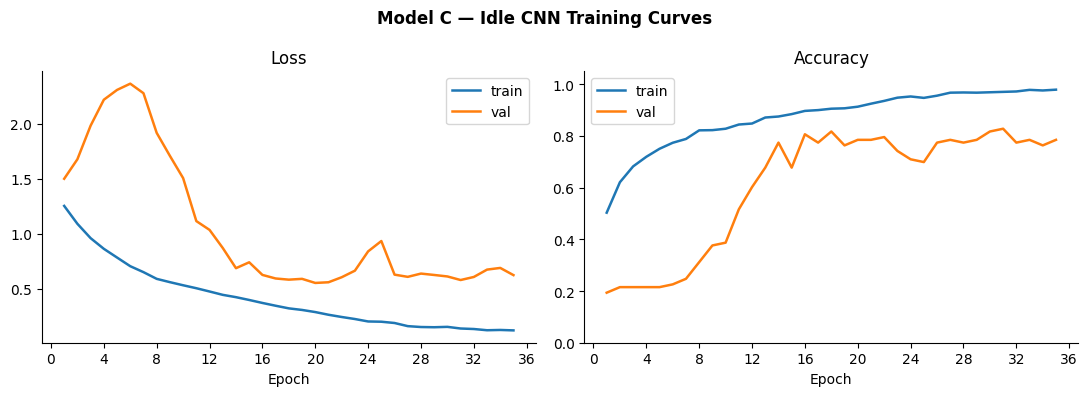

In [6]:
plot_training_curves(history)

from IPython.display import Image
Image('results/training_curves/idle_curves.png')

## 6 — Evaluation

In [7]:
_, val_acc  = model.evaluate(X_val,  y_val,  verbose=0)
_, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f'Val  accuracy : {val_acc:.4f}  ({val_acc*100:.1f}%)')
print(f'Test accuracy : {test_acc:.4f}  ({test_acc*100:.1f}%)')

Val  accuracy : 0.7849  (78.5%)
Test accuracy : 0.7419  (74.2%)


## 7 — Confusion Matrix

Saved -> c:\Users\HP8CG\Revio\results\confusion_matrices\idle_cm.png


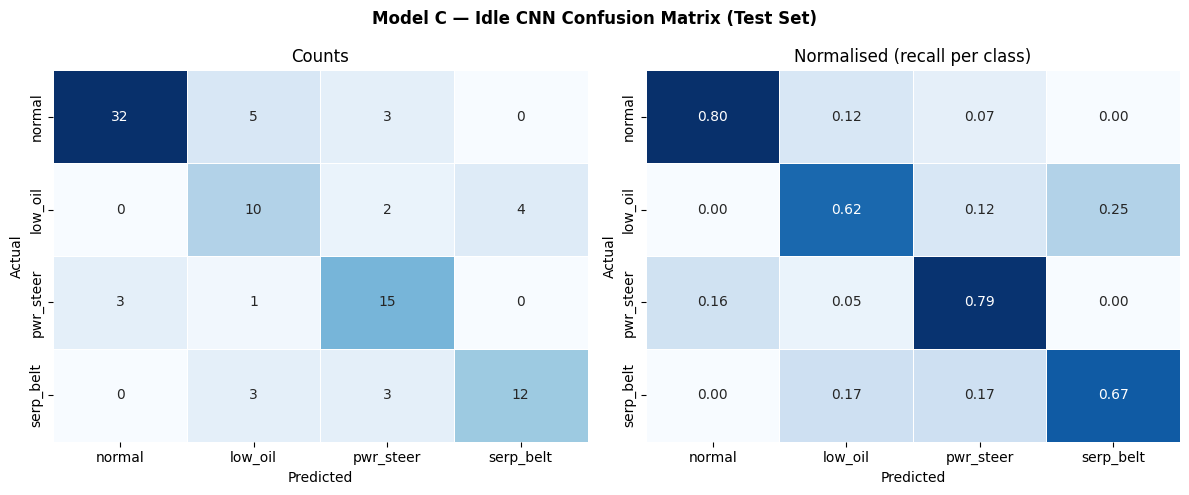

In [8]:
y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
plot_confusion_matrix(y_test, y_pred, label_names)

from IPython.display import Image
Image('results/confusion_matrices/idle_cm.png')

## 8 — Per-Class Report

In [9]:
from sklearn.metrics import classification_report
short_names = ['normal', 'low_oil', 'pwr_steer', 'serp_belt']
print(classification_report(y_test, y_pred, target_names=short_names))

              precision    recall  f1-score   support

      normal       0.91      0.80      0.85        40
     low_oil       0.53      0.62      0.57        16
   pwr_steer       0.65      0.79      0.71        19
   serp_belt       0.75      0.67      0.71        18

    accuracy                           0.74        93
   macro avg       0.71      0.72      0.71        93
weighted avg       0.76      0.74      0.75        93



## 9 — Confidence Score Inspection

In [10]:
probs = model.predict(X_test, verbose=0)
confidence = probs.max(axis=1)
pred_labels = [label_names[i] for i in probs.argmax(axis=1)]
true_labels = [label_names[i] for i in y_test]

print('Confidence stats on test set:')
print(f'  mean  : {confidence.mean():.3f}')
print(f'  min   : {confidence.min():.3f}')
print(f'  median: {np.median(confidence):.3f}')
print()

# Per-class confidence breakdown
print('Mean confidence per true class:')
for i, name in enumerate(label_names):
    mask = y_test == i
    if mask.sum() > 0:
        print(f'  {name:<25} mean_conf={confidence[mask].mean():.3f}  '
              f'correct={int((np.array(pred_labels)[mask] == np.array(true_labels)[mask]).sum())}/{mask.sum()}')

# Low confidence predictions
print()
threshold = 0.85
low_conf = [(true_labels[i], pred_labels[i], confidence[i])
            for i in range(len(y_test)) if confidence[i] < threshold]
if low_conf:
    print(f'Predictions below {threshold} confidence ({len(low_conf)} samples):')
    for true, pred, conf in sorted(low_conf, key=lambda x: x[2]):
        tag = 'OK' if true == pred else 'WRONG'
        print(f'  [{tag}]  true={true:<25} pred={pred:<25} conf={conf:.3f}')
else:
    print(f'All test predictions above {threshold} confidence.')

Confidence stats on test set:
  mean  : 0.828
  min   : 0.382
  median: 0.896

Mean confidence per true class:
  normal_engine_idle        mean_conf=0.847  correct=32/40
  low_oil                   mean_conf=0.767  correct=10/16
  power_steering            mean_conf=0.815  correct=15/19
  serpentine_belt           mean_conf=0.852  correct=12/18

Predictions below 0.85 confidence (41 samples):
  [WRONG]  true=normal_engine_idle        pred=power_steering            conf=0.382
  [WRONG]  true=normal_engine_idle        pred=power_steering            conf=0.436
  [OK]  true=power_steering            pred=power_steering            conf=0.446
  [OK]  true=normal_engine_idle        pred=normal_engine_idle        conf=0.459
  [OK]  true=normal_engine_idle        pred=normal_engine_idle        conf=0.469
  [WRONG]  true=serpentine_belt           pred=low_oil                   conf=0.485
  [WRONG]  true=serpentine_belt           pred=low_oil                   conf=0.488
  [OK]  true=power_steeri

## Summary

| Metric | Value |
|---|---|
| Val accuracy  | *(filled after run)* |
| Test accuracy | *(filled after run)* |
| Model size (float32) | ~(filled after run)* KB |
| Class weights applied | Yes — balanced for 2.25x imbalance |
| Model saved | `models/idle_model.h5` |
| Next step | TFLite conversion — `04_tflite_conversion_benchmark.ipynb` |